In [27]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data'

from src.preprocess import preprocess_pipeline
from src.recommender import FEATURE_RANGES, AUDIO_FEATURES
from src.vibes import VIBE_ANCHORS
PRIMARY = '#1db954'; ACCENT = '#535353'

df, audio_matrix, scaler, kmeans = preprocess_pipeline(str(DATA / 'spotify_data.csv'))
print('catalogue:', len(df), 'songs   clusters:', kmeans.n_clusters)

catalogue: 1159748 songs   clusters: 20


## Audio-feature distributions (vs. Heavy Metal anchor)

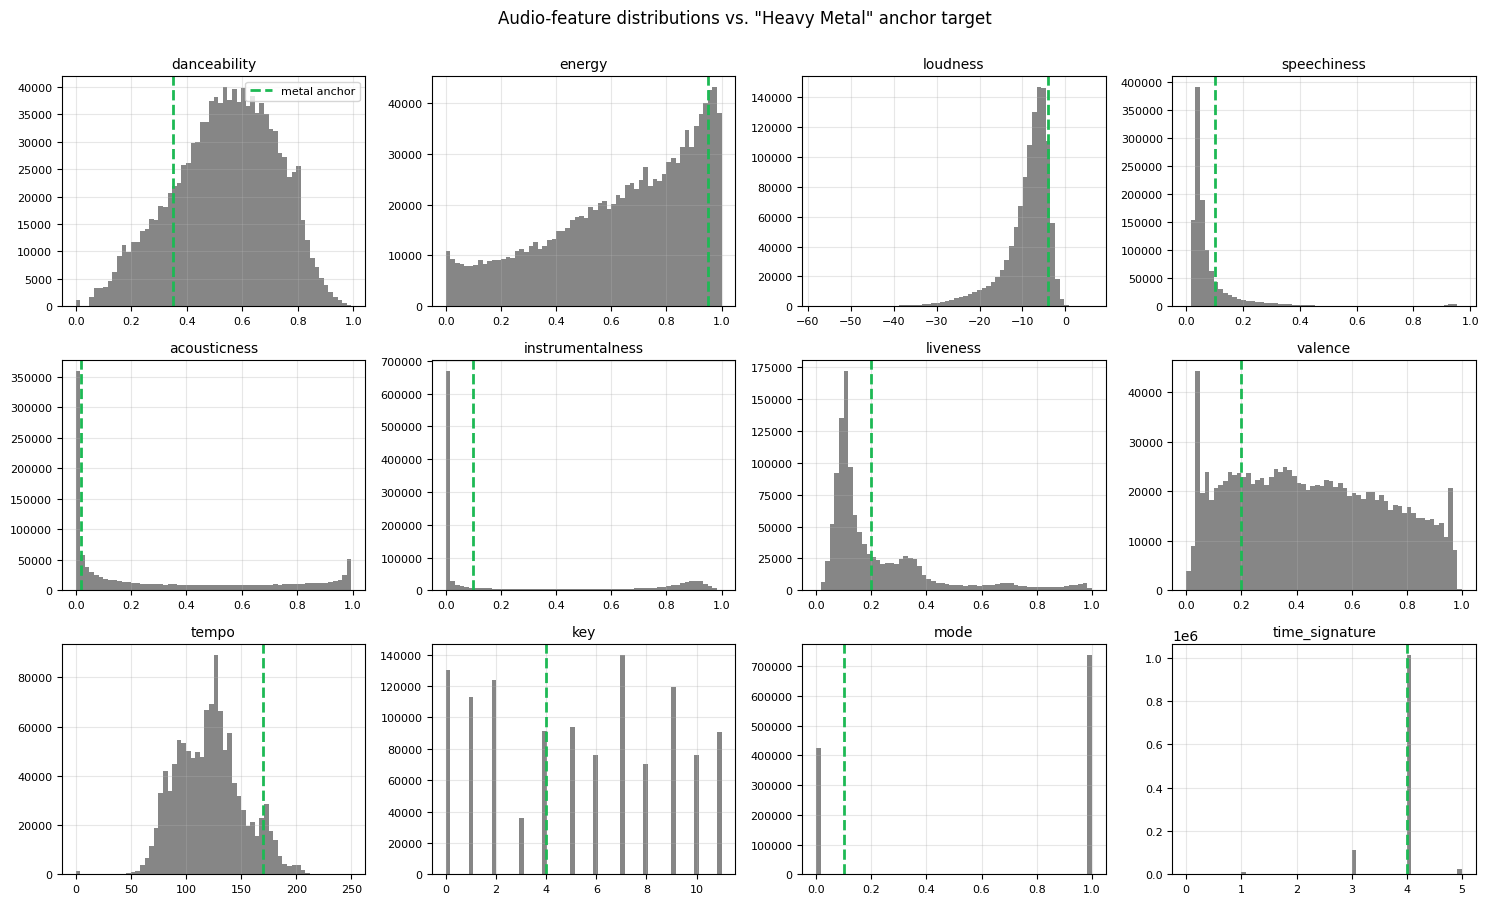

In [28]:
metal_anchor = next(a for a in VIBE_ANCHORS if 'heavy metal' in a['description'])
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, feat in zip(axes.flat, AUDIO_FEATURES):
    ax.hist(df[feat].values, bins=60, color=ACCENT, alpha=0.7)
    ax.axvline(metal_anchor['features'][feat], color=PRIMARY, lw=2, linestyle='--', label='metal anchor')
    ax.set_title(feat, fontsize=10); ax.tick_params(labelsize=8); ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, loc='upper right')
fig.suptitle('Audio-feature distributions vs. "Heavy Metal" anchor target', fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

## F K-Means cluster profiles (heatmap)

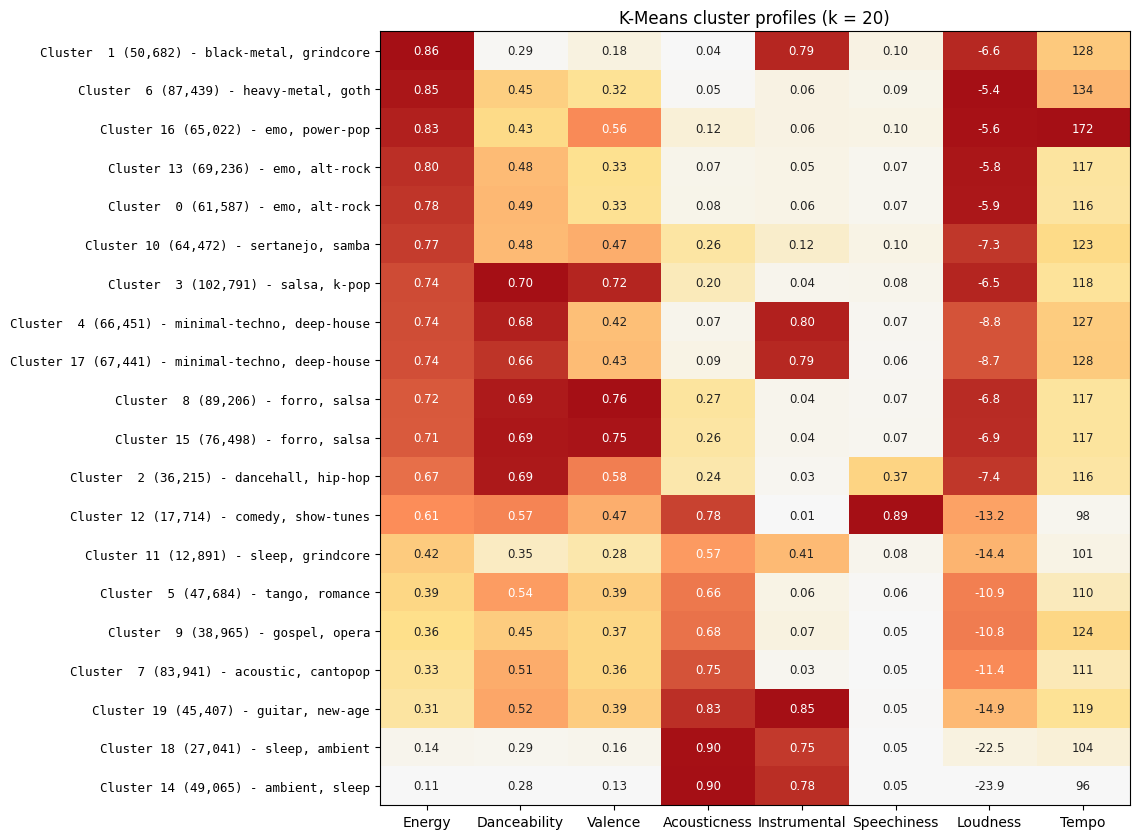

In [29]:
FEATURE_COLS = ['energy','danceability','valence','acousticness','instrumentalness','speechiness','loudness','tempo']
LABELS = {'energy':'Energy','danceability':'Danceability','valence':'Valence','acousticness':'Acousticness','instrumentalness':'Instrumental','speechiness':'Speechiness','loudness':'Loudness','tempo':'Tempo'}
profile = df.groupby('cluster')[FEATURE_COLS].mean()
profile['size'] = df['cluster'].value_counts().sort_index()
profile['top_genres'] = df.groupby('cluster')['genre'].agg(lambda s: ', '.join(s.value_counts().head(2).index.tolist()))
profile = profile.sort_values('energy', ascending=False)
disp = profile[FEATURE_COLS]; norm = (disp - disp.min()) / (disp.max() - disp.min())
fig, ax = plt.subplots(figsize=(11.5, 8.5))
cmap = LinearSegmentedColormap.from_list('t', ['#f7f7f7','#fee08b','#fc8d59','#a50f15'])
ax.imshow(norm.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)
for i in range(len(profile)):
    for j, col in enumerate(FEATURE_COLS):
        v = profile.iloc[i][col]
        t = f'{v:.0f}' if col == 'tempo' else (f'{v:.1f}' if col == 'loudness' else f'{v:.2f}')
        ax.text(j, i, t, ha='center', va='center', fontsize=8.5, color=('white' if norm.iloc[i, j] > 0.6 else '#222'))
ax.set_yticks(range(len(profile)))
ax.set_yticklabels([f"Cluster {int(c):>2} ({int(profile.loc[c,'size']):>6,d}) - {profile.loc[c,'top_genres']}" for c in profile.index], fontsize=9, fontfamily='monospace')
ax.set_xticks(range(len(FEATURE_COLS))); ax.set_xticklabels([LABELS[c] for c in FEATURE_COLS], fontsize=10)
ax.set_title('K-Means cluster profiles (k = 20)'); plt.tight_layout(); plt.show()

K-Means clusters in 2-D PCA projection

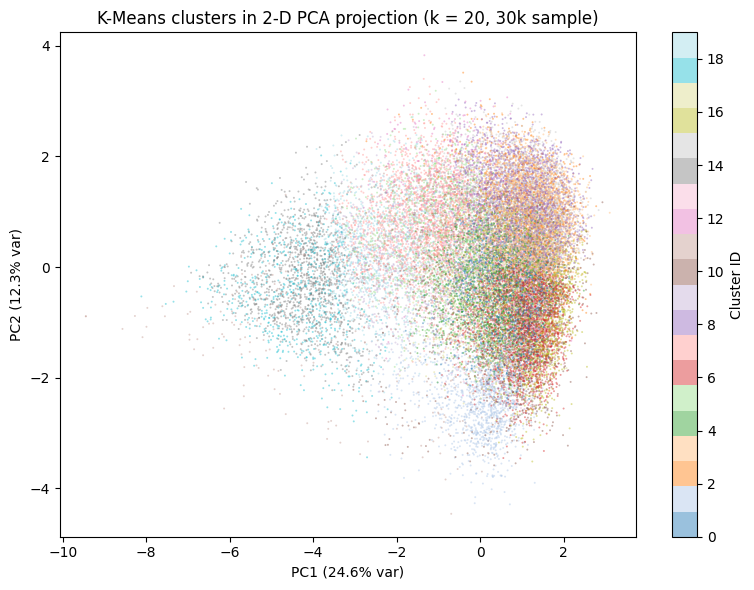

In [30]:
from sklearn.decomposition import PCA
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(30000, len(df)), replace=False)
X = audio_matrix[idx]; labels = df.iloc[idx]['cluster'].values
pca = PCA(n_components=2, random_state=42); Z = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z[:,0], Z[:,1], c=labels, cmap=plt.get_cmap('tab20', 20), s=2, alpha=0.45, linewidths=0)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('K-Means clusters in 2-D PCA projection (k = 20, 30k sample)')
fig.colorbar(sc, ax=ax, ticks=range(0, 20, 2), label='Cluster ID')
plt.tight_layout(); plt.show()

## Alpha sweep

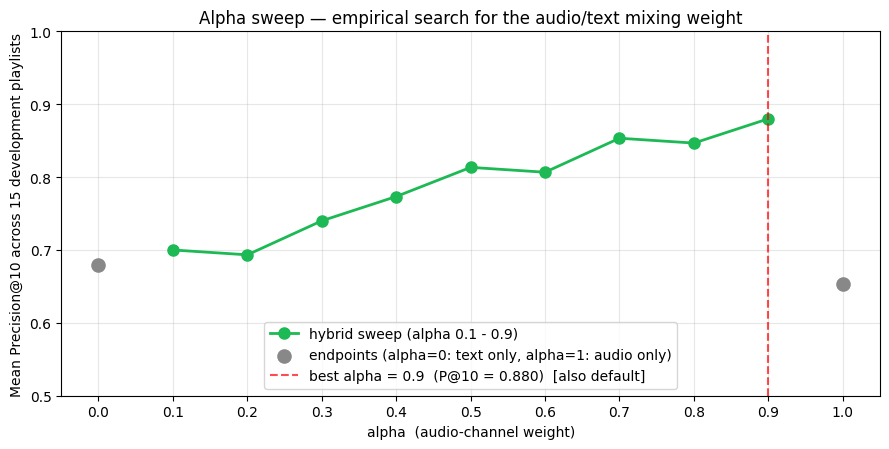

In [32]:
adf = pd.read_csv(DATA / 'alpha_sweep_results.csv')
interior = adf[(adf['alpha'] > 0.0) & (adf['alpha'] < 1.0)]
endpoints = adf[(adf['alpha'] == 0.0) | (adf['alpha'] == 1.0)]
bi = adf['P@10_mean'].idxmax(); ba = float(adf.loc[bi, 'alpha']); bp = float(adf.loc[bi, 'P@10_mean'])
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(interior['alpha'], interior['P@10_mean'], marker='o', color='#1db954', linewidth=2, markersize=8, label='hybrid sweep (alpha 0.1 - 0.9)')
ax.scatter(endpoints['alpha'], endpoints['P@10_mean'], color='#888888', s=90, zorder=5, label='endpoints (alpha=0: text only, alpha=1: audio only)')
ax.axvline(ba, color='red', linestyle='--', alpha=0.7, label=f'best alpha = {ba:.1f}  (P@10 = {bp:.3f})  [also default]')
ax.set_xlabel('alpha  (audio-channel weight)')
ax.set_ylabel('Mean Precision@10 across 15 development playlists')
ax.set_title('Alpha sweep — empirical search for the audio/text mixing weight')
ax.set_xticks(np.arange(0.0, 1.05, 0.1)); ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.3); ax.legend(loc='lower center')
plt.tight_layout(); plt.show()

## Cluster-anchor ablation

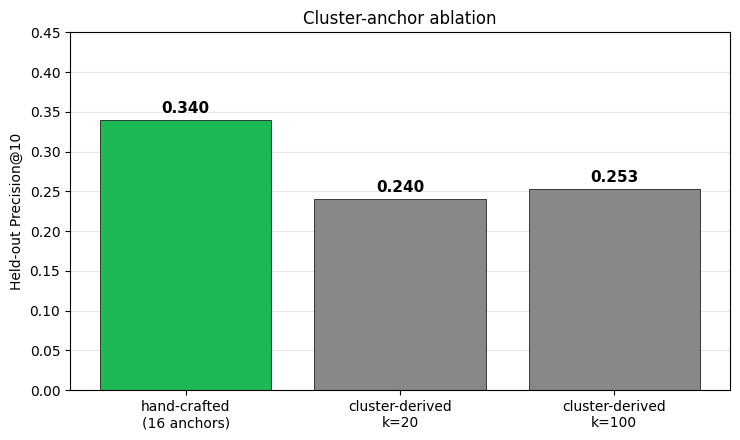

In [33]:
labels = ['hand-crafted\n(16 anchors)', 'cluster-derived\nk=20', 'cluster-derived\nk=100']
values = [0.340, 0.240, 0.253]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(labels, values, color=['#1db954','#888','#888'], edgecolor='black', linewidth=0.5)
for b, v in zip(bars, values): ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Held-out Precision@10'); ax.set_ylim(0, 0.45)
ax.set_title('Cluster-anchor ablation'); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

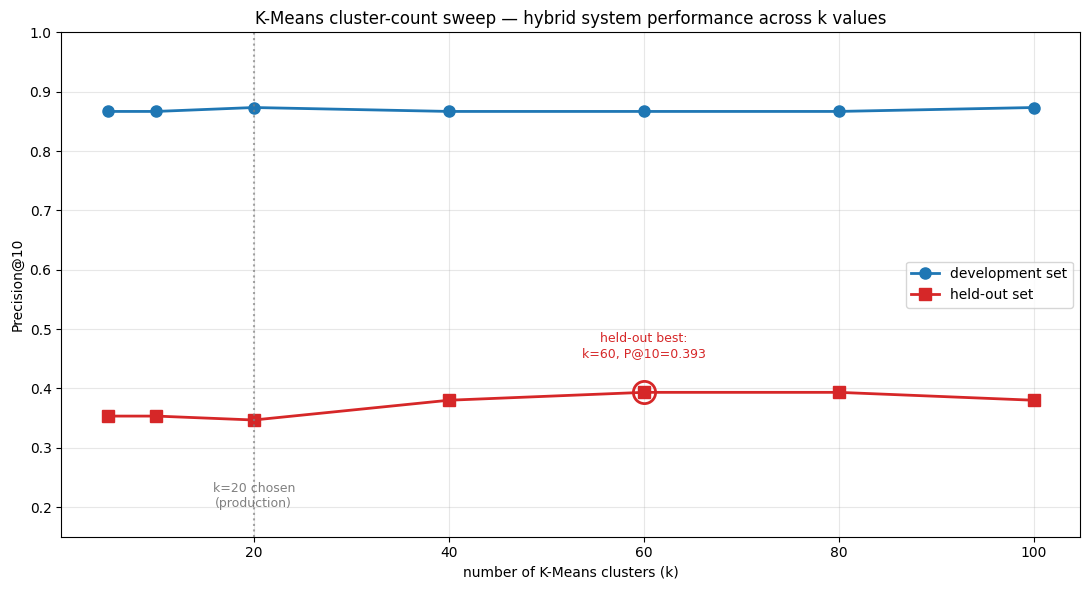

In [34]:
p = DATA / 'cluster_comparison_results' / 'k_sweep.csv'
s = pd.read_csv(p)
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(s['k'], s['dev_mean_p@10'], 'o-', color='#1f77b4', linewidth=2, markersize=8, label='development set')
ax.plot(s['k'], s['held_out_mean_p@10'], 's-', color='#d62728', linewidth=2, markersize=8, label='held-out set')
ax.axvline(20, color='gray', linestyle=':', alpha=0.7)
ax.annotate('k=20 chosen\n(production)', xy=(20, 0.20), fontsize=9, color='gray', ha='center')
bi = s['held_out_mean_p@10'].idxmax(); bk = int(s.loc[bi, 'k']); bv = float(s.loc[bi, 'held_out_mean_p@10'])
ax.plot(bk, bv, 'o', color='#d62728', markersize=16, markerfacecolor='none', markeredgewidth=2)
ax.annotate(f'held-out best:\nk={bk}, P@10={bv:.3f}', xy=(bk, bv), xytext=(bk, bv + 0.06), fontsize=9, color='#d62728', ha='center')
ax.set_xlabel('number of K-Means clusters (k)')
ax.set_ylabel('Precision@10')
ax.set_title('K-Means cluster-count sweep — hybrid system performance across k values')
ax.set_ylim(0.15, 1.0); ax.grid(alpha=0.3); ax.legend(loc='center right')
plt.tight_layout(); plt.show()